In [4]:
import pandas as pd

In [6]:
import numpy as np

In [14]:
import matplotlib.pyplot as plt

In [20]:
import seaborn as sns

In [22]:
#Cargamos dataset sucio
dfSucio = pd.read_csv("dataset_sucio_practica.csv")

In [28]:
#se cargan dataset sucio
dfSucio.shape

(125, 8)

In [30]:
dfSucio.head()

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
1,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
2,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí


In [32]:
dfSucio.tail()

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
120,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
121,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
122,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
123,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
124,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí


In [34]:
dfSucio.describe()

,id,edad,salario
count,125.000000,110.000000,107.000000
mean,58.200000,43.945455,14093.457944
std,35.906465,47.489803,8825.918852
min,1.000000,-5.000000,-1000.000000
25%,27.000000,22.750000,12000.000000
50%,58.000000,30.000000,15000.000000
75%,89.000000,40.000000,18000.000000
max,120.000000,150.000000,25000.000000


In [36]:
dfSucio[dfSucio["id"].isin([29,55,58])]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
28,29,Teresa Ramos,22.0,rileyraymond@hotmail.com,México,-1000.0,2025-08-29,NaN
54,55,John Lewis,NaN,rodriguezbrett@yahoo.com,México,-1000.0,2024-07-03,NaN
57,58,Michael Barajas,40.0,antoniocox@hotmail.com,España,15000.0,2026-05-02,NaN


In [40]:
#Generamos una copia "por cualquier cosa"
dfCopy = dfSucio.copy()

In [42]:
dfSucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              125 non-null    int64  
 1   nombre          116 non-null    object 
 2   edad            110 non-null    float64
 3   correo          125 non-null    object 
 4   pais            82 non-null     object 
 5   salario         107 non-null    float64
 6   fecha_registro  125 non-null    object 
 7   activo          90 non-null     object 
dtypes: float64(2), int64(1), object(5)
memory usage: 7.9+ KB


<function matplotlib.pyplot.show(close=None, block=None)>

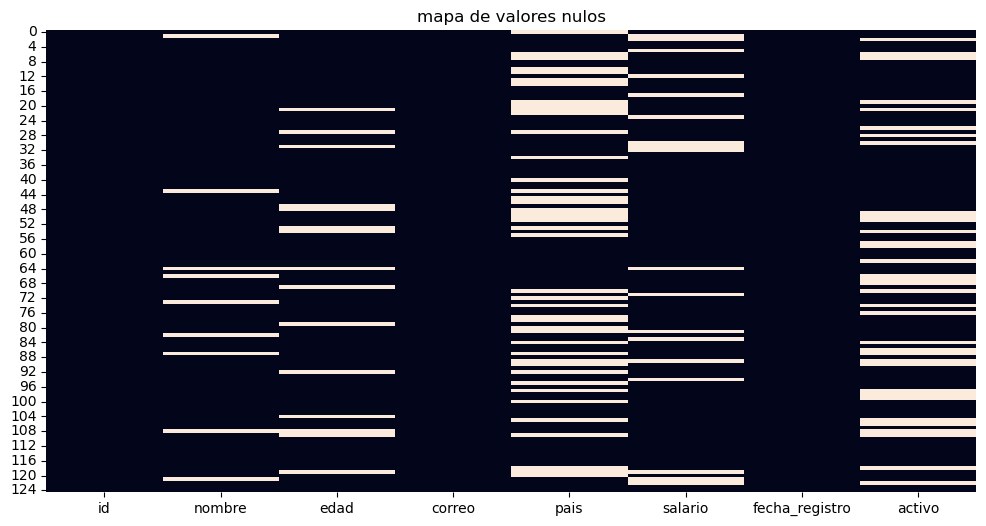

In [46]:
plt.figure(figsize = (12,6 ))
sns.heatmap(dfSucio.isnull(), cbar = False)
plt.title("mapa de valores nulos")
plt.show

In [52]:
#Limpieza de datos
dfSucio.duplicated().sum()

0

In [50]:
#Borrando datos duplicados
dfSucio.drop_duplicates(inplace=True)

In [62]:
#Corregir edades invalidas
dfSucio[(dfSucio["edad"] <0 ) | (dfSucio["edad"]>110) ]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo


In [60]:
dfSucio.loc[(dfSucio["edad"] <0) | (dfSucio["edad"]>110), "edad"] = np.nan

In [64]:
#Calcular variable de la edad
mediana_edad = dfSucio ["edad"].median()

In [66]:
mediana_edad

30.0

In [70]:
dfSucio["edad"] = dfSucio["edad"].fillna (mediana_edad)

In [72]:
dfSucio["edad"].describe()

count    120.000000
mean      30.325000
std        4.745918
min       22.000000
25%       30.000000
50%       30.000000
75%       31.250000
max       40.000000
Name: edad, dtype: float64

In [78]:
#corregir anomalias de salarios minimos
dfSucio[dfSucio ["salario"]<0]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo


In [76]:
dfSucio.loc[(dfSucio["salario"] <0), "salario" ] = np.nan

In [86]:
mediana_salario = dfSucio["salario"] .median()

In [88]:
mediana_salario

15000.0

In [90]:
dfSucio["salario"] = dfSucio["salario"] .fillna(mediana_salario)

In [92]:
dfSucio["salario"].describe()

count      120.000000
mean     16741.666667
std       4401.099621
min      12000.000000
25%      15000.000000
50%      15000.000000
75%      18000.000000
max      25000.000000
Name: salario, dtype: float64

In [98]:
#Corregir correos "NO validos"
dfSucio[~dfSucio["correo"] .str.contains("@",na = False)]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
3,4,Joyce Williams,30.0,<NA>,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,30.0,<NA>,México,25000.0,2025-03-28,Sí
18,19,Nicholas Curry,35.0,<NA>,México,12000.0,2025-11-22,Sí
21,22,Carrie Griffith,30.0,<NA>,NaN,15000.0,2025-05-05,NaN
30,31,Mrs. Sara Johnson,35.0,<NA>,Argentina,15000.0,2026-03-07,NaN
40,41,Cynthia Arnold,30.0,<NA>,NaN,25000.0,2024-11-03,No
65,66,Michael Lopez,40.0,<NA>,España,15000.0,2025-12-01,No
78,79,Charles Page,25.0,<NA>,NaN,15000.0,2025-09-01,No
87,88,NaN,22.0,<NA>,NaN,12000.0,2025-03-07,NaN
88,89,Erika Bernard,30.0,<NA>,Argentina,12000.0,2024-11-16,Sí


In [96]:
#correos no validos
correo_invalido = ~dfSucio["correo"] .str.contains("@",na = False)
dfSucio.loc [correo_invalido, "correo"] = pd.NA

In [110]:
#Corregir paises no asignados
dfSucio["pais"].isnull().sum()

0

In [102]:
moda_pais = dfSucio["pais"].mode()[0]

In [108]:
moda_pais

'Argentina'

In [106]:
dfSucio["pais"] =dfSucio["pais"].fillna(moda_pais)

In [118]:
dfSucio.dtypes

id                         int64
nombre                    object
edad                     float64
correo                    object
pais                      object
salario                  float64
fecha_registro    datetime64[ns]
activo                    object
dtype: object

In [116]:
#convertimos la fecha a "datetime"
dfSucio["fecha_registro"] = pd.to_datetime(dfSucio["fecha_registro"]) 

In [120]:
dfSucio["fecha_registro"] .dt.year

0      2026
1      2026
2      2026
3      2025
4      2025
       ... 
115    2024
116    2024
117    2026
118    2025
119    2026
Name: fecha_registro, Length: 120, dtype: int32

In [124]:
#categorizar el campo activo
dfSucio["activo"] .value_counts(dropna = False)

activo
Sí     47
No     39
NaN    34
Name: count, dtype: int64

In [126]:
dfSucio ["activo"] = dfSucio ["activo"].fillna ("Sí")

In [128]:
dfSucio["activo"] .value_counts(dropna = False)

activo
Sí    81
No    39
Name: count, dtype: int64

In [132]:
#convertido a binario
dfSucio ["activo"] = dfSucio ["activo"] .map ({
    "Sí":1, 
    "No" : 0
})

In [134]:
dfSucio["activo"] .value_counts(dropna = False)

activo
1    81
0    39
Name: count, dtype: int64

In [140]:
(dfSucio.isnull().sum()/len (dfSucio) *100)

id                 0.000000
nombre             6.666667
edad               0.000000
correo            10.000000
pais               0.000000
salario            0.000000
fecha_registro     0.000000
activo             0.000000
dtype: float64

# conclusiones
Durante la practica se identificaron y corrigieron los siguientes problemas:
1. Borrar los datos duplicados
2. Corregir datos invalidos y atipicos
3. Realizar y corregir tipos de datos
4. Categorizar campos que sean necesarios